# Phishing Website Detection using Machine Learning

## Notebook 04: Baseline Model Building

### Objective

The objective of this notebook is to train and evaluate multiple baseline machine learning models using the engineered phishing website dataset. The performance of these models will serve as a benchmark for further improvement through hyperparameter tuning.

---


## 1. Import Libraries

Import the required libraries for model training, evaluation, and saving the trained models.

In [37]:
# Load saved preprocessing objects and save trained models
import joblib

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Baseline linear classifier
from sklearn.linear_model import LogisticRegression
# Tree-based classifier
from sklearn.tree import DecisionTreeClassifier
# Ensemble tree model
from sklearn.ensemble import RandomForestClassifier

# Gradient Boosting
from xgboost import XGBClassifier
# LightGBM implementation
from lightgbm import LGBMClassifier
# CatBoost implementation
from catboost import CatBoostClassifier

# sklearn.metrics for Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Confusion matrix visualization
import matplotlib.pyplot as plt

## 2. Load the Engineered Dataset

Load the engineered phishing website dataset created in the previous notebook.

In [38]:
df = pd.read_csv("../dataset/engineered_phishing_dataset.csv")

df.head()

,num_dots_url,num_hyph_url,num_underline_url,num_slash_url,num_questionmark_url,num_equal_url,at_sign_url,num_exclamation_url,num_space_url,tilde_url,...,at_sign_param,num_exclamation_param,num_space_param,tilde_param,num_comma_param,num_plus_param,num_asterisk_param,num_percent_param,tld_in_param,phishing
0,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,5,1,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,2,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 4. Separate Features and Target

**Question:** Which columns represent the input features and the target variable?

Separate the dataset into input features (`X`) and the target variable (`y`) for model training.

In [39]:
X = df.drop("phishing", axis=1)
y = df["phishing"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (4129, 56)
Target Shape: (4129,)


### Interpretation

- The input features are stored in **X**.
- The target variable (`phishing`) is stored in **y**.
- These will be used to train and evaluate the machine learning models.

---

## 5. Split the Dataset

**Question:** How should the dataset be divided for training and testing?

Split the dataset into training and testing sets. The training set is used to train the models, while the testing set is used to evaluate their performance on unseen data.

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (3303, 56)
Testing Set: (826, 56)


### Interpretation

- **80%** of the data is used for training.
- **20%** of the data is reserved for testing.
- Stratified sampling preserves the class distribution in both sets.

---

## 6. Feature Scaling

**Question:** Why is feature scaling required?

Some machine learning algorithms perform better when the input features are on a similar scale. Standardization transforms the features to have a mean of 0 and a standard deviation of 1.

In [41]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Interpretation

- The scaler is fitted only on the training data.
- The same transformation is then applied to the testing data.
- This prevents information from the testing set from influencing the training process.

---

## 7. Save Preprocessed Data

Save the training dataset, testing dataset, and fitted scaler for reuse in subsequent notebooks.

In [42]:
import joblib

joblib.dump(X_train_scaled, "../models/preprocessed_data/X_train.pkl")
joblib.dump(X_test_scaled, "../models/preprocessed_data/X_test.pkl")
joblib.dump(y_train, "../models/preprocessed_data/y_train.pkl")
joblib.dump(y_test, "../models/preprocessed_data/y_test.pkl")

print("Preprocessed datasets saved successfully!")

joblib.dump(scaler,"../models/preprocessed_data/standard_scaler.pkl")

print("Scaler saved successfully")

Preprocessed datasets saved successfully!
Scaler saved successfully


## 8. Define the Machine Learning Models

This project evaluates multiple supervised machine learning algorithms for phishing website detection.

The selected models represent different learning approaches, including linear models, tree-based models, ensemble learning methods, and gradient boosting algorithms.

Using multiple algorithms allows a fair comparison of their predictive performance on the same dataset.

In [43]:
'''
    ML algo involve randomness (e.g., random initialization, random feature selection, random sampling).
    "random_state = 42" ensures that the model produces the same results every time the notebook is executed.
'''

models= {   

    # max_iter=1000  : Allows optimizer to converge and prevents convergence warnings.
    "Logistic Regression" : LogisticRegression(random_state = 42, max_iter = 1000),

    "Decision Tree" : DecisionTreeClassifier(random_state = 42),

    # n_jobs=-1 : Allows the algorithm to use all available CPU cores simultaneously and reduces training time.
    "Random Forest" : RandomForestClassifier(random_state = 42, n_jobs = -1),

    # XGBoost requires an evaluation metric during training.
    # eval_metric="logloss" : Specifies binary classification evaluation metric.
    # n_jobs=-1 : Uses all CPU cores.
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss", n_jobs=-1),

    # LightGBM prints many informational messages during training.
    # verbose=-1 : suppresses these messages.
    "LightGBM" : LGBMClassifier(random_state = 42, verbose = -1),

    # CatBoost displays training progress for every boosting iteration.
    # verbose=0 : disables this output.
    "CatBoost" : CatBoostClassifier(random_state = 42, verbose = 0)
}
print(f"{len(models)} models initialized successfully")

6 models initialized successfully


## 9. Create Helper Functions

Training and evaluating multiple machine learning models often requires writing the same code repeatedly. To avoid duplication and improve code readability, reusable helper functions are created.

The following helper functions will be implemented:

- **train_model()** – Trains a machine learning model using the training dataset.
- **evaluate_model()** – Computes the evaluation metrics including Accuracy, Precision, Recall, and F1-Score.
- **plot_confusion_matrix()** – Displays the confusion matrix for visual performance analysis.
- **save_trained_model()** – Saves the trained model for future inference and deployment.

Using these reusable functions ensures a consistent evaluation process across all machine learning models and significantly reduces repetitive code.

### 9.1 Train Model

This function trains a machine learning model using the training dataset and returns the fitted model.

Creating a reusable training function avoids writing the same training code for every algorithm.

In [44]:
def train_model(model, X_train, y_train):
    """
    Train a machine learning model.
    """
    
    model.fit(X_train, y_train)
    
    return model

### 9.2 Evaluate Model

This function evaluates the trained model using the testing dataset.

The following evaluation metrics are calculated:

- Accuracy
- Precision
- Recall
- F1-Score

The function also returns the predicted labels for further analysis.

In [45]:
def evaluate_model(model, X_test, y_test):
    """
    Evaluate a trained model and return performance metrics.
    """
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

### 9.3 Plot Confusion Matrix

The confusion matrix summarizes the classification performance of each machine learning model by comparing the predicted labels with the actual labels.

It reports the number of:

- True Positives (TP): Phishing websites correctly identified.
- True Negatives (TN): Legitimate websites correctly identified.
- False Positives (FP): Only a few legitimate websites were incorrectly classified as phishing.
- False Negatives (FN): Only a few phishing websites were misclassified as legitimate.

A good classifier aims to maximize the diagonal values (TP and TN) while minimizing off-diagonal errors (FP and FN). The confusion matrix complements evaluation metrics such as accuracy, precision, recall, and F1-score by providing a detailed view of prediction outcomes.

In [46]:
def plot_confusion_matrix(model, X_test, y_test):
    """
    Plot the confusion matrix.
    """
    
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Legitimate", "Phishing"]
    ).plot(cmap="Blues")
    
    plt.title("Confusion Matrix")
    plt.show()

### 9.4 Save Trained Model

After training, each model is saved to disk using Joblib.

Saving the trained models allows them to be reused later for model comparison, explainability (SHAP), and deployment without retraining.

In [47]:
def save_trained_model(model, model_name):
    """
    Save a trained machine learning model.
    """

    joblib.dump(model, f"../models/baseline/{model_name}.pkl")

    print(f"{model_name} model saved successfully.")

## 10. Train and Evaluate Machine Learning Models

Each machine learning model is trained using the training dataset and evaluated on the testing dataset.

The helper functions created in the previous section simplify the workflow by performing training, evaluation, confusion matrix visualization, and model saving with minimal code.

The evaluation metrics of every model are stored in a single results table for later comparison.

In [48]:
# create a single comparison table of all six models
results={}


### 10.1 Train Logistic Regression

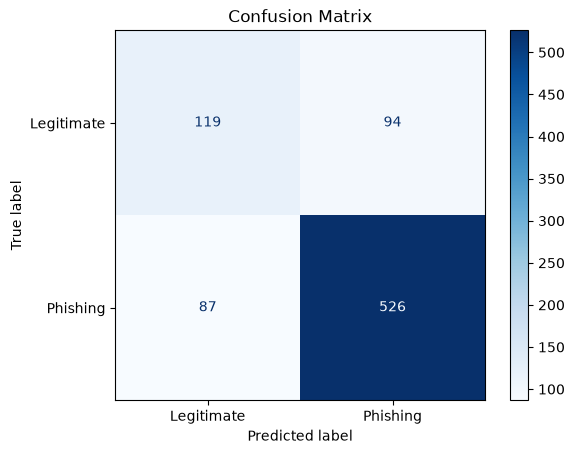

Logistic_Regression model saved successfully.


In [49]:
# Training Linear Regression model
model = train_model(
    models["Logistic Regression"],
    X_train,
    y_train)

# Evaluation of the trained Logistic Regression Model
metrics = evaluate_model(
    model,
    X_test,
    y_test
)

# Plot the confusion Matrix (Trained Model Performance)
plot_confusion_matrix(
    model,
    X_test,
    y_test
)

# Save the trained Linear Regression Model
save_trained_model(
    model,
    "Logistic_Regression"
)

# Store metrics for comparison
results["Logistic Regression"] = metrics


### 10.2 Train Decison Tree

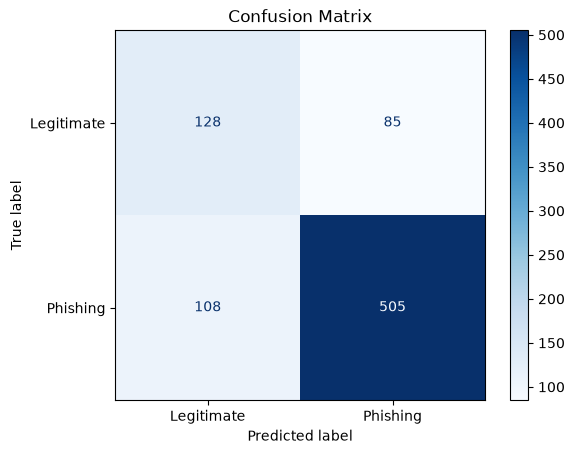

Decision_Tree model saved successfully.


In [50]:
# Training Decision Tree model
model = train_model(
    models["Decision Tree"],
    X_train,
    y_train
)

# Evaluation of the trained Decision Tree Model
metrics = evaluate_model(
    model,
    X_test,
    y_test
)

# Plot confusion matrix (Trained Model Performance)
plot_confusion_matrix(
    model,
    X_test,
    y_test
)

# Save the trained Decision Tree model
save_trained_model(
    model,
    "Decision_Tree"
)

# Store metrics for comparison
results["Decision Tree"] = metrics

### 10.3 Train Random Forest

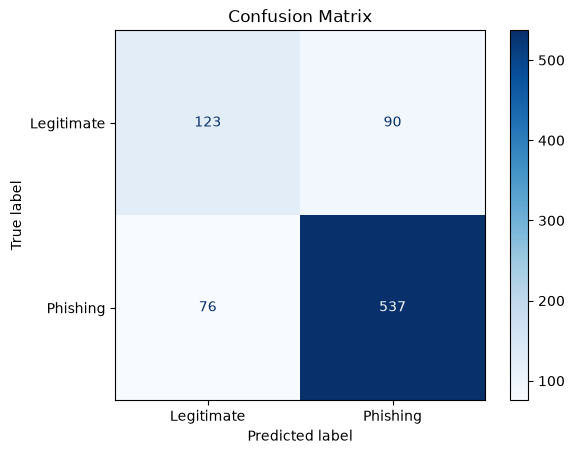

Random_Forest model saved successfully.


In [51]:
# Training Random Forest model
model = train_model(
    models["Random Forest"],
    X_train,
    y_train
)

# Evaluation of the trained Random Forest Model
metrics = evaluate_model(
    model,
    X_test,
    y_test
)

# Plot confusion matrix (Trained Model Performance)
plot_confusion_matrix(
    model,
    X_test,
    y_test
)

# Save the trained Random Forest model
save_trained_model(
    model,
    "Random_Forest"
)

# Store metrics for comparison
results["Random Forest"] = metrics

### 10.4 Train XGBoost

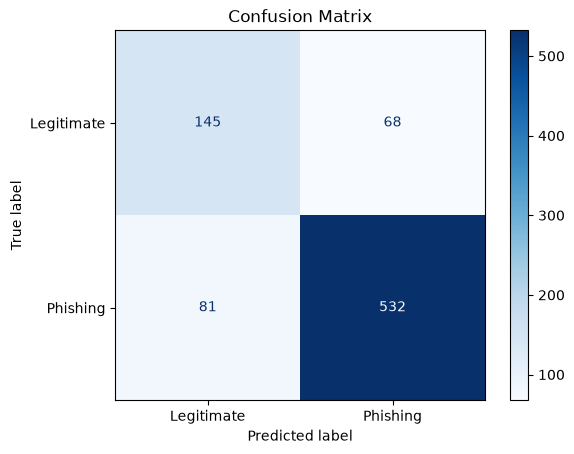

XGBoost model saved successfully.


In [52]:
# Training XGBoost model
model = train_model(
    models["XGBoost"],
    X_train,
    y_train
)

# Evaluation of the trained XGBoost Model
metrics = evaluate_model(
    model,
    X_test,
    y_test
)

# Plot confusion matrix (Trained Model Performance)
plot_confusion_matrix(
    model,
    X_test,
    y_test
)

# Save the trained XGBoost model
save_trained_model(
    model,
    "XGBoost"
)

# Store metrics for comparison
results["XGBoost"] = metrics

### 10.5 Train LightGBM

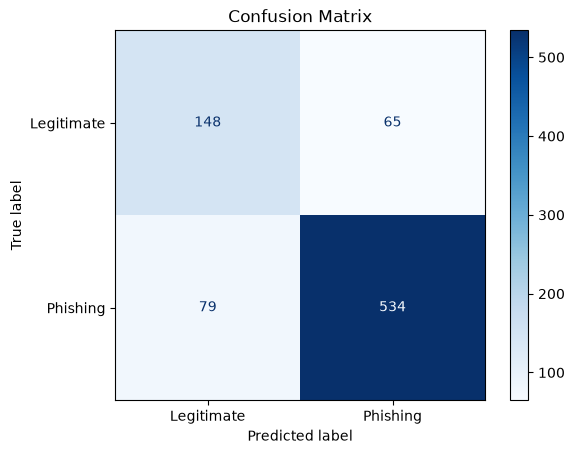

LightGBM model saved successfully.


In [53]:
# Training LightGBM Model
model = train_model(
    models["LightGBM"],
    X_train,
    y_train
)

# Evaluation of trained LightGBM
metrics = evaluate_model(
    model,
    X_test,
    y_test
)

# Plot Confusion Matrix (Trained Model Performance)
plot_confusion_matrix(
    model,
    X_test,
    y_test
)

# Save the trained LightGBM Model
save_trained_model(
    model,
    "LightGBM"
)

# Store metrics for comparison
results["LightGBM"] = metrics

### 10.6 Train CatBoost 

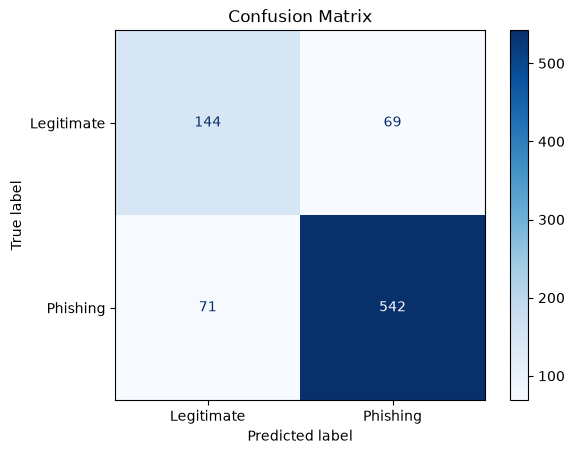

CatBoost model saved successfully.


In [54]:
# Training CatBoost Model
model = train_model(
    models["CatBoost"],
    X_train,
    y_train
)

# Evaluation of trained CatBoost
metrics = evaluate_model(
    model,
    X_test,
    y_test
) 

# Plot Confusion Matrix (Trained Model Performance)
plot_confusion_matrix(
    model,
    X_test,
    y_test
)

# Save the trained CatBoost Mode;
save_trained_model(
    model,
    "CatBoost"
)

# Store metrics for comparison
results["CatBoost"] = metrics

## 11. Compare Model Performance

After training all machine learning models, their performance is compared using standard classification metrics.

The comparison includes Accuracy, Precision, Recall, and F1-score, allowing the strengths and weaknesses of each algorithm to be evaluated on the same testing dataset.

A tabular comparison makes it easier to identify the most suitable model for phishing website detection.

In [55]:
# .T stands for Transpose in pandas.
# Using .T rearranges the table so that each row represents one ML model.

results_df = pd.DataFrame(results).T

results_df = results_df.round(4)

results_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.7809,0.8484,0.8581,0.8532
Decision Tree,0.7663,0.8559,0.8238,0.8396
Random Forest,0.7990,0.8565,0.8760,0.8661
XGBoost,0.8196,0.8867,0.8679,0.8772
LightGBM,0.8257,0.8915,0.8711,0.8812
CatBoost,0.8305,0.8871,0.8842,0.8856


## 12. Rank the Models

Sort the trained machine learning models based on their classification performance to identify the strongest baseline model.

In [56]:
results_df = results_df.sort_values(
    by=["Accuracy", "F1 Score"],
    ascending=False
)

results_df

,Accuracy,Precision,Recall,F1 Score
CatBoost,0.8305,0.8871,0.8842,0.8856
LightGBM,0.8257,0.8915,0.8711,0.8812
XGBoost,0.8196,0.8867,0.8679,0.8772
Random Forest,0.7990,0.8565,0.8760,0.8661
Logistic Regression,0.7809,0.8484,0.8581,0.8532
Decision Tree,0.7663,0.8559,0.8238,0.8396


## 13. Identify the Best Performing Model

The best-performing algorithm is identified based on the evaluation metrics.

This model will be used in subsequent notebooks for explainability (SHAP), deployment, and real-time phishing website prediction.

In [57]:
best_model = results_df.index[0]

print(f"Best Baseline Model : {best_model}")

Best Baseline Model : CatBoost


## 14. Save Model Comparison Results

The performance comparison table is saved for future analysis, visualization, and inclusion in the project report.

Saving the evaluation results also avoids recomputing metrics each time the notebook is executed.

In [58]:
results_df.to_csv("../reports/model_comparison.csv", index=True)

print("Comparison table saved successfully!")

Comparison table saved successfully!


## 15. Key Findings

- Six baseline machine learning models were trained and evaluated.
- Their performance was compared using Accuracy, Precision, Recall, and F1 Score.
- **CatBoost achieved the best overall performance among the baseline models.**
- All trained models and the comparison table were saved for future use.

## 16. Conclusion

This notebook established the baseline performance of six machine learning models for phishing website detection. Among the evaluated models, **CatBoost** achieved the highest performance and was selected as the best baseline model. In the next notebook, this model will be further optimized through hyperparameter tuning to improve its predictive performance.

In [59]:
model = joblib.load("../models/baseline/CatBoost.pkl")

y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.8305084745762712


In [61]:
import os

print(os.path.abspath("../models/baseline/CatBoost.pkl"))

d:\Phishing_Website_Detection\kaggle_multi_dataset\models\baseline\CatBoost.pkl


In [60]:
import os

print(os.getcwd())

d:\Phishing_Website_Detection\kaggle_multi_dataset\notebooks
